In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/nsw-australia-electricity-demand-2018-2023")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 2.23M/2.23M [00:01<00:00, 1.32MB/s]

Extracting files...
Path to dataset files: C:\Users\acer\.cache\kagglehub\datasets\joebeachcapital\nsw-australia-electricity-demand-2018-2023\versions\1


## Reading each excel file and forming a Combined DataFrame

In [66]:
import pandas as pd
import glob

# Specify the folder path containing the CSV files
folder_path = '1/*.csv'

# Use glob to get all CSV files in the folder
csv_files = glob.glob(folder_path)

In [67]:
# Create an empty list to store DataFrames
dfs = []

# Loop through each CSV file and read it into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

In [68]:
# Concatenate all DataFrames into one
combined_df = pd.concat(dfs, ignore_index=True)

In [69]:
combined_df

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2018/01/01 00:30:00,6912.25,91.86,TRADE
1,NSW1,2018/01/01 01:00:00,6745.63,88.83,TRADE
2,NSW1,2018/01/01 01:30:00,6466.06,73.62,TRADE
3,NSW1,2018/01/01 02:00:00,6279.80,71.49,TRADE
4,NSW1,2018/01/01 02:30:00,6177.31,69.27,TRADE
...,...,...,...,...,...
248587,NSW1,2023/06/27 23:40:00,8536.43,116.99,TRADE
248588,NSW1,2023/06/27 23:45:00,8527.02,89.00,TRADE
248589,NSW1,2023/06/27 23:50:00,8489.29,88.88,TRADE
248590,NSW1,2023/06/27 23:55:00,8358.07,61.74,TRADE


In [70]:
combined_df.drop(['REGION','PERIODTYPE'], axis = 1, inplace = True)

In [71]:
combined_df.head()

,SETTLEMENTDATE,TOTALDEMAND,RRP
0,2018/01/01 00:30:00,6912.25,91.86
1,2018/01/01 01:00:00,6745.63,88.83
2,2018/01/01 01:30:00,6466.06,73.62
3,2018/01/01 02:00:00,6279.80,71.49
4,2018/01/01 02:30:00,6177.31,69.27


In [72]:
combined_df['SETTLEMENTDATE'] = pd.to_datetime(combined_df['SETTLEMENTDATE'])

In [73]:
dates = combined_df.sort_values(by = 'SETTLEMENTDATE')['SETTLEMENTDATE']

In [74]:
demands = combined_df.sort_values(by = 'SETTLEMENTDATE')['TOTALDEMAND']

In [75]:
import matplotlib.pyplot as plt

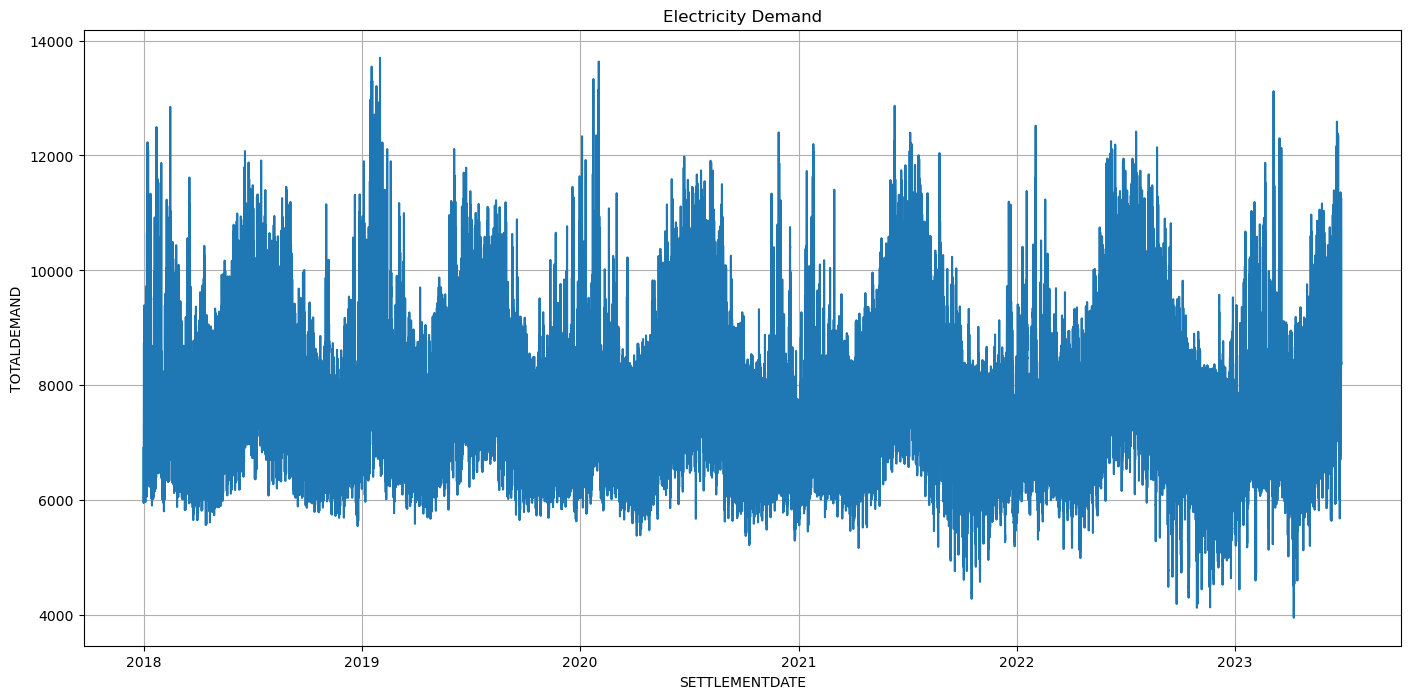

In [76]:
plt.figure(figsize = (17,8))
plt.plot(dates, demands)

# Add labels and title
plt.xlabel('SETTLEMENTDATE')
plt.ylabel('TOTALDEMAND')
plt.title('Electricity Demand')

# Show grid for readability
plt.grid(True)

# Display the plot
plt.show()

## Resampling the Large Dataset by calculating the mean of each week

In [77]:
df = pd.concat([dates, demands], axis = 1)

In [78]:
df.sort_values(by = 'SETTLEMENTDATE', inplace = True)

In [79]:
df

,SETTLEMENTDATE,TOTALDEMAND
0,2018-01-01 00:30:00,6912.25
1,2018-01-01 01:00:00,6745.63
2,2018-01-01 01:30:00,6466.06
3,2018-01-01 02:00:00,6279.80
4,2018-01-01 02:30:00,6177.31
...,...,...
248587,2023-06-27 23:40:00,8536.43
248588,2023-06-27 23:45:00,8527.02
248589,2023-06-27 23:50:00,8489.29
248590,2023-06-27 23:55:00,8358.07


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 248592 entries, 0 to 248591
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   SETTLEMENTDATE  248592 non-null  datetime64[ns]
 1   TOTALDEMAND     248592 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.7 MB


In [81]:
df.columns = df.columns.str.strip()

In [82]:
df.set_index('SETTLEMENTDATE', inplace=True)

In [83]:
df_resampled = df.resample('W').mean()  # Resample by week (you can use 'M' for monthly)
df_resampled = df_resampled.reset_index()

In [84]:
df_resampled

,SETTLEMENTDATE,TOTALDEMAND
0,2018-01-07,8009.906537
1,2018-01-14,8384.092589
2,2018-01-21,7972.035238
3,2018-01-28,8909.238899
4,2018-02-04,7926.977976
...,...,...
282,2023-06-04,8017.623963
283,2023-06-11,8098.516806
284,2023-06-18,8360.181939
285,2023-06-25,8953.052837


In [85]:
import pyaf.ForecastEngine as autof

# Initialize the forecast engine
engine = autof.cForecastEngine()

# Train the model with the sampled data
engine.train(df_resampled, 'SETTLEMENTDATE', 'TOTALDEMAND', iHorizon = 30)  # Forecast for 30 days

# Generate the forecast for the next 30 days
forecast_df = engine.forecast(df_resampled, iHorizon=30)

# Display forecasted values
print(forecast_df[['SETTLEMENTDATE', 'TOTALDEMAND_Forecast']])

INFO:pyaf.std:TRAINING_ENGINE_START {'Signals': ['TOTALDEMAND'], 'Horizons': {'TOTALDEMAND': 30}}
DEBUG:pyaf.detailed:DETAIL_MESSAGE('KEPT_DISCARDED_MODELS', 160, 158, 2)
INFO:pyaf.std:TRAINING_ENGINE_END 54.667
INFO:pyaf.std:FORECASTING_ENGINE_START {'Signals': ['TOTALDEMAND'], 'Horizons': {'TOTALDEMAND': 30}}
INFO:pyaf.std:FORECASTING_ENGINE_END 0.893


    SETTLEMENTDATE  TOTALDEMAND_Forecast
0       2018-01-07           8044.571364
1       2018-01-14           8044.622723
2       2018-01-21           7945.238438
3       2018-01-28           8830.589568
4       2018-02-04           8430.444687
..             ...                   ...
312     2023-12-31           7332.288274
313     2024-01-07           8044.571364
314     2024-01-14           8044.622723
315     2024-01-21           7945.238438
316     2024-01-28           8830.589568

[317 rows x 2 columns]


In [34]:
# Train the model on the original dataset with daily frequency
df2 = pd.concat([dates, demands], axis = 1)
engine2 = autof.cForecastEngine()
engine2.train(df2, 'SETTLEMENTDATE', 'TOTALDEMAND', 365)  # Forecast for 365 days

INFO:pyaf.std:TRAINING_ENGINE_START {'Signals': ['TOTALDEMAND'], 'Horizons': {'TOTALDEMAND': 365}}
INFO:pyaf.std:TRAINING_ENGINE_END 609.594


In [24]:
# Generate the forecast for the next 30 days
forecast_df2 = engine2.forecast(df2, iHorizon=365)

# Display forecasted values
print(forecast_df2[['SETTLEMENTDATE', 'TOTALDEMAND_Forecast']])

INFO:pyaf.std:FORECASTING_ENGINE_START {'Signals': ['TOTALDEMAND'], 'Horizons': {'TOTALDEMAND': 365}}
INFO:pyaf.std:FORECASTING_ENGINE_END 57.286


            SETTLEMENTDATE  TOTALDEMAND_Forecast
0      2018-01-01 00:30:00              8013.665
1      2018-01-01 01:00:00              7598.835
2      2018-01-01 01:30:00              7598.835
3      2018-01-01 02:00:00              7127.210
4      2018-01-01 02:30:00              7127.210
...                    ...                   ...
248952 2023-06-29 06:05:00              8293.265
248953 2023-06-29 06:10:00              8293.265
248954 2023-06-29 06:15:00              8293.265
248955 2023-06-29 06:20:00              8293.265
248956 2023-06-29 06:25:00              8293.265

[248957 rows x 2 columns]


NameError: name 'forecast_df2' is not defined

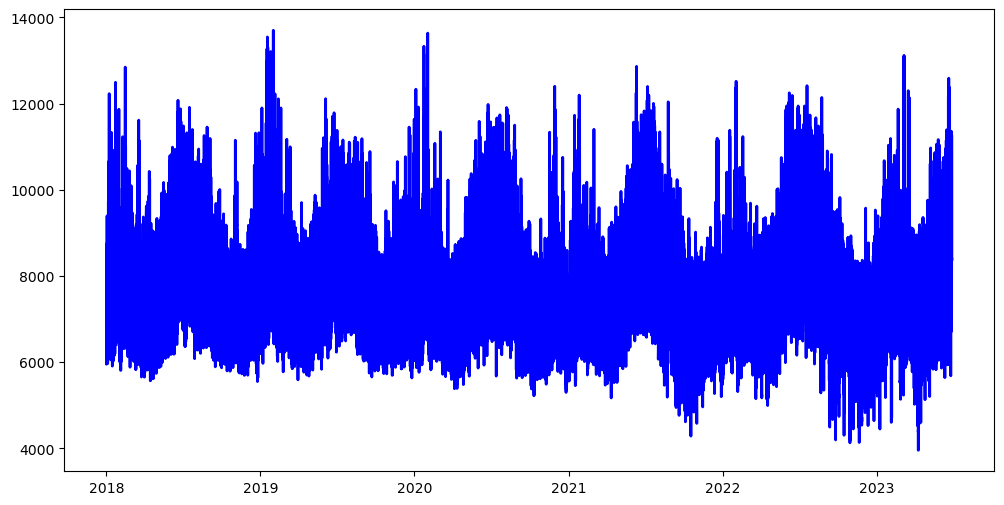

In [86]:
import matplotlib.pyplot as plt

# Plot the historical and forecasted data
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(df2['SETTLEMENTDATE'], df2['TOTALDEMAND'], label='Historical Demand', color='blue', linewidth=2)

# Plot forecasted data
plt.plot(forecast_df2['SETTLEMENTDATE'], forecast_df2['TOTALDEMAND_Forecast'], label='Forecasted Demand', color='orange', linestyle='--', linewidth=2)

# Add confidence intervals if available
if 'TOTALDEMAND_Lower_Bound' in forecast_df2.columns and 'TOTALDEMAND_Upper_Bound' in forecast_df2.columns:
    plt.fill_between(forecast_df2['SETTLEMENTDATE'], forecast_df2['TOTALDEMAND_Lower_Bound'], forecast_df2['TOTALDEMAND_Upper_Bound'], color='orange', alpha=0.3, label='Forecast Interval')

# Highlight the forecast start
plt.axvline(x=df2['SETTLEMENTDATE'].iloc[-1], color='red', linestyle='--', label='Forecast Start')

# Add labels and title
plt.xlabel('SETTLEMENTDATE')
plt.ylabel('TOTALDEMAND')
plt.title('Electricity Demand Forecast (Sampled Data)')

# Add a legend
plt.legend(loc='best')

# Show grid for readability
plt.grid(True)

# Display the plot
plt.show()

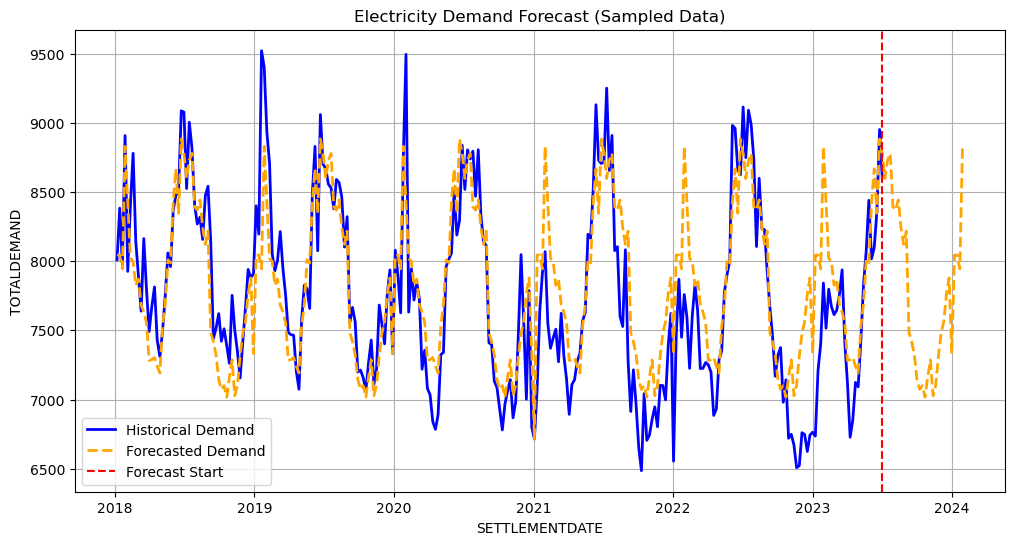

In [87]:
import matplotlib.pyplot as plt

# Plot the historical and forecasted data
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(df_resampled['SETTLEMENTDATE'], df_resampled['TOTALDEMAND'], label='Historical Demand', color='blue', linewidth=2)

# Plot forecasted data
plt.plot(forecast_df['SETTLEMENTDATE'], forecast_df['TOTALDEMAND_Forecast'], label='Forecasted Demand', color='orange', linestyle='--', linewidth=2)

# Add confidence intervals if available
if 'TOTALDEMAND_Lower_Bound' in forecast_df.columns and 'TOTALDEMAND_Upper_Bound' in forecast_df.columns:
    plt.fill_between(forecast_df['SETTLEMENTDATE'], forecast_df['TOTALDEMAND_Lower_Bound'], forecast_df['TOTALDEMAND_Upper_Bound'], color='orange', alpha=0.3, label='Forecast Interval')

# Highlight the forecast start
plt.axvline(x=df_resampled['SETTLEMENTDATE'].iloc[-1], color='red', linestyle='--', label='Forecast Start')

# Add labels and title
plt.xlabel('SETTLEMENTDATE')
plt.ylabel('TOTALDEMAND')
plt.title('Electricity Demand Forecast (Sampled Data)')

# Add a legend
plt.legend(loc='best')

# Show grid for readability
plt.grid(True)

# Display the plot
plt.show()


In [36]:
from joblib import dump

# Save the model
dump(engine, 'forecasting_model.joblib')


['forecasting_model.joblib']

In [37]:
pd.__version__

'1.5.3'

In [61]:
from joblib import load
eng = load('forecasting_model.joblib')

In [62]:
data = pd.read_csv("resampled.csv")
data = data[['date', 'demand']].rename(columns={"date":"SETTLEMENTDATE","demand": "TOTALDEMAND"})
data['SETTLEMENTDATE'] = pd.to_datetime(data['SETTLEMENTDATE'])

In [88]:
forecastt = eng.forecast(data, iHorizon=30)

INFO:pyaf.std:FORECASTING_ENGINE_START {'Signals': ['TOTALDEMAND'], 'Horizons': {'TOTALDEMAND': 30}}
INFO:pyaf.std:FORECASTING_ENGINE_END 0.44


In [89]:
forecastt[['SETTLEMENTDATE', 'TOTALDEMAND_Forecast']].tail(30)

,SETTLEMENTDATE,TOTALDEMAND_Forecast
287,2023-07-09,8598.723438
288,2023-07-16,8730.885595
289,2023-07-23,8779.582217
290,2023-07-30,8393.355030
291,2023-08-06,8369.798616
292,2023-08-13,8443.694301
293,2023-08-20,8244.749330
294,2023-08-27,8122.132857
295,2023-09-03,8217.853199
296,2023-09-10,7483.686176


In [90]:
# Categorize forecast into weeks and months
forecastt['Week'] = forecastt['SETTLEMENTDATE'].dt.isocalendar().week
forecastt['Month'] = forecastt['SETTLEMENTDATE'].dt.month

In [91]:
forecastt

,SETTLEMENTDATE,TOTALDEMAND,TOTALDEMAND_scaled,_TOTALDEMAND,row_number,SETTLEMENTDATE_Normalized,_TOTALDEMAND_ConstantTrend,_TOTALDEMAND_ConstantTrend_residue,_TOTALDEMAND_ConstantTrend_residue_Seasonal_WeekOfYear,_TOTALDEMAND_ConstantTrend_residue_Seasonal_WeekOfYear_residue,...,TOTALDEMAND_Forecast_Upper_Bound,TOTALDEMAND_Forecast_Quantile_8,TOTALDEMAND_Forecast_Quantile_22,TOTALDEMAND_Forecast_Quantile_36,TOTALDEMAND_Forecast_Quantile_50,TOTALDEMAND_Forecast_Quantile_64,TOTALDEMAND_Forecast_Quantile_78,TOTALDEMAND_Forecast_Quantile_92,Week,Month
0,2018-01-07,8009.906537,0.501990,0.501990,0,0.000000,0.43845,0.063540,0.074951,-0.011411,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,2018-01-14,8384.092589,0.625163,0.625163,1,0.004902,0.43845,0.186713,0.074968,0.111745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1
2,2018-01-21,7972.035238,0.489524,0.489524,2,0.009804,0.43845,0.051074,0.042253,0.008821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
3,2018-01-28,8909.238899,0.798029,0.798029,3,0.014706,0.43845,0.359579,0.333689,0.025889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1
4,2018-02-04,7926.977976,0.474692,0.474692,4,0.019608,0.43845,0.036242,0.201971,-0.165729,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,2023-12-31,NaN,NaN,NaN,312,1.529412,0.43845,NaN,-0.159516,NaN,...,8135.742058,7016.385503,7187.359478,7332.711947,7510.038824,7634.155882,7789.461392,8105.917874,52,12
313,2024-01-07,NaN,NaN,NaN,313,1.534314,0.43845,NaN,0.074951,NaN,...,8848.025148,7728.668593,7899.642568,8044.995037,8222.321914,8346.438972,8501.744482,8818.200964,1,1
314,2024-01-14,NaN,NaN,NaN,314,1.539216,0.43845,NaN,0.074968,NaN,...,8848.076507,7728.719952,7899.693927,8045.046396,8222.373274,8346.490331,8501.795841,8818.252324,2,1
315,2024-01-21,NaN,NaN,NaN,315,1.544118,0.43845,NaN,0.042253,NaN,...,8748.692221,7629.335666,7800.309641,7945.662111,8122.988988,8247.106046,8402.411556,8718.868038,3,1
